In [10]:
import pandas as pd
import os

processed_path = r"C:\Users\Pawan\OneDrive\Desktop\Online-Retail-II\Online-retail-demand-forcasting\data\processed"

daily_demand_model = pd.read_csv(
    os.path.join(processed_path, "daily_demand_features.csv")
)

daily_demand_model["date"] = pd.to_datetime(
    daily_demand_model["date"]
)

print("Dataset shape:", daily_demand_model.shape)

Dataset shape: (1431, 18)


In [11]:
daily_demand_model = (
    daily_demand_model
    .sort_values('date')
    .reset_index(drop=True)
)

split_index = int(len(daily_demand_model) * 0.8)

train = daily_demand_model.iloc[:split_index].copy()
test = daily_demand_model.iloc[split_index:].copy()

print("Training:", train.shape)
print("Testing:", test.shape)

print("\nTraining period:")
print(train['date'].min(), "to", train['date'].max())

print("\nTesting period:")
print(test['date'].min(), "to", test['date'].max())

Training: (1144, 18)
Testing: (287, 18)

Training period:
2022-01-31 00:00:00 to 2025-03-19 00:00:00

Testing period:
2025-03-20 00:00:00 to 2025-12-31 00:00:00


In [12]:
features = [
    'year',
    'month',
    'quarter',
    'day_of_week',
    'day',
    'week_of_year',
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',
    'rolling_7',
    'rolling_14',
    'rolling_30'
]

X_train = train[features]
y_train = train['demand']

X_test = test[features]
y_test = test['demand']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1144, 14)
y_train: (1144,)
X_test: (287, 14)
y_test: (287,)


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Random Forest Results")
print("---------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

Random Forest Results
---------------------
MAE : 414.74951219512184
RMSE: 524.6155179422865
MAPE: 2.857986100101045 %


In [15]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.0


In [16]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print("XGBoost Results")
print("----------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape, "%")

XGBoost Results
----------------
MAE : 417.4488525390625
RMSE: 521.3400701557478
MAPE: 2.87498186238487 %


In [18]:
import matplotlib.pyplot as plt

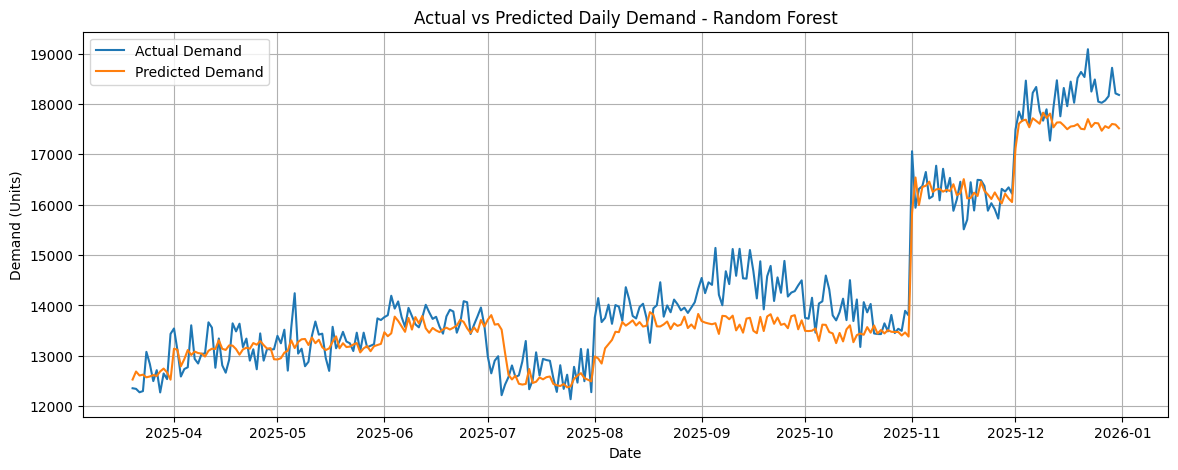

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    test['date'],
    y_test.values,
    label='Actual Demand'
)

plt.plot(
    test['date'],
    y_pred,
    label='Predicted Demand'
)

plt.title('Actual vs Predicted Daily Demand - Random Forest')
plt.xlabel('Date')
plt.ylabel('Demand (Units)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance

month           0.717546
lag_1           0.187497
rolling_7       0.057872
lag_30          0.012634
day             0.005227
rolling_30      0.003680
rolling_14      0.003543
lag_7           0.003456
lag_14          0.003258
week_of_year    0.001914
year            0.001619
day_of_week     0.001065
quarter         0.000473
is_weekend      0.000218
dtype: float64

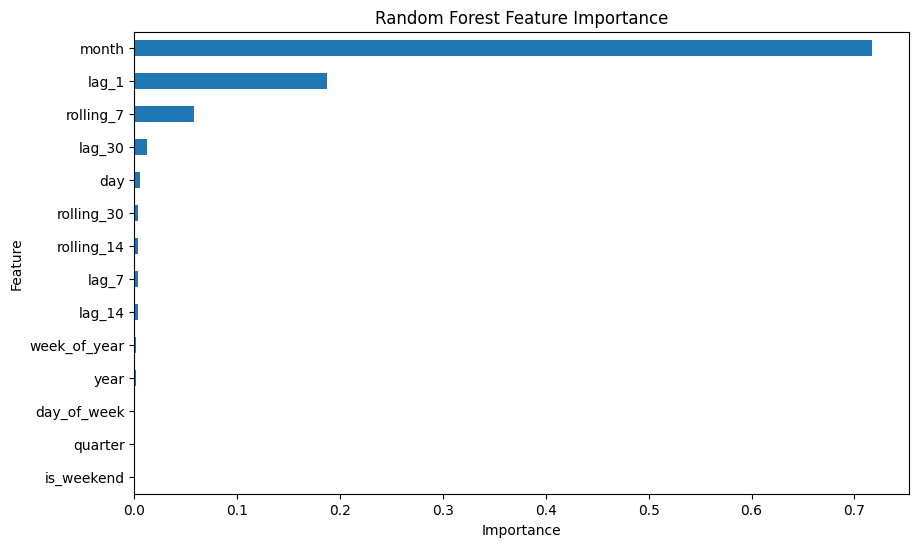

In [21]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [22]:
baseline_pred = test['lag_1']

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mape = np.mean(
    np.abs((y_test - baseline_pred) / y_test)
) * 100

print("Naive Baseline Results")
print("----------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape, "%")

Naive Baseline Results
----------------------
MAE : 366.52613240418117
RMSE: 486.847724978841
MAPE: 2.557459089321219 %


In [23]:
daily_demand_model['lag_28'] = daily_demand_model['demand'].shift(28)

daily_demand_model['rolling_28'] = (
    daily_demand_model['demand']
    .shift(1)
    .rolling(28)
    .mean()
)

daily_demand_model['rolling_std_7'] = (
    daily_demand_model['demand']
    .shift(1)
    .rolling(7)
    .std()
)

daily_demand_model[['date', 'demand', 'lag_28', 'rolling_28', 'rolling_std_7']].tail()

,date,demand,lag_28,rolling_28,rolling_std_7
1426,2025-12-27,18070,16344.0,17977.571429,372.931374
1427,2025-12-28,18156,16219.0,18039.214286,384.005208
1428,2025-12-29,18719,17491.0,18108.392857,381.333500
1429,2025-12-30,18211,17851.0,18152.250000,261.298042
1430,2025-12-31,18180,17666.0,18165.107143,261.720862


In [24]:
daily_demand_model = daily_demand_model.dropna().copy()

daily_demand_model = (
    daily_demand_model
    .sort_values('date')
    .reset_index(drop=True)
)

print(daily_demand_model.shape)

(1403, 21)


In [25]:
train = daily_demand_model.iloc[:1122].copy()
test = daily_demand_model.iloc[1122:].copy()

print(train.shape)
print(test.shape)

(1122, 21)
(281, 21)


In [26]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [27]:
# ============================================================
# ARIMA MODEL
# ============================================================

arima_model = ARIMA(
    train['demand'],
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                 1122
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8532.942
Date:                Mon, 24 Aug 2026   AIC                          17071.885
Time:                        19:24:27   BIC                          17086.951
Sample:                             0   HQIC                         17077.579
                               - 1122                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1474      0.130     -1.131      0.258      -0.403       0.108
ma.L1         -0.1149      0.131     -0.880      0.379      -0.371       0.141
sigma2      2.389e+05   1988.147    120.171      0.0

In [28]:
# Generate forecast for the test period

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

print("ARIMA Forecast:")
print(arima_forecast.head())

ARIMA Forecast:
1122    12876.656634
1123    12870.811590
1124    12871.673099
1125    12871.546120
1126    12871.564835
Name: predicted_mean, dtype: float64


In [29]:
# ============================================================
# ARIMA EVALUATION
# ============================================================

arima_mae = mean_absolute_error(
    test['demand'],
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test['demand'],
        arima_forecast
    )
)

arima_mape = np.mean(
    np.abs(
        (test['demand'].values - arima_forecast.values)
        / test['demand'].values
    )
) * 100

print("\nARIMA Results")
print("-" * 30)
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"MAPE : {arima_mape:.2f}%")


ARIMA Results
------------------------------
MAE  : 1557.41
RMSE : 2233.95
MAPE : 9.84%


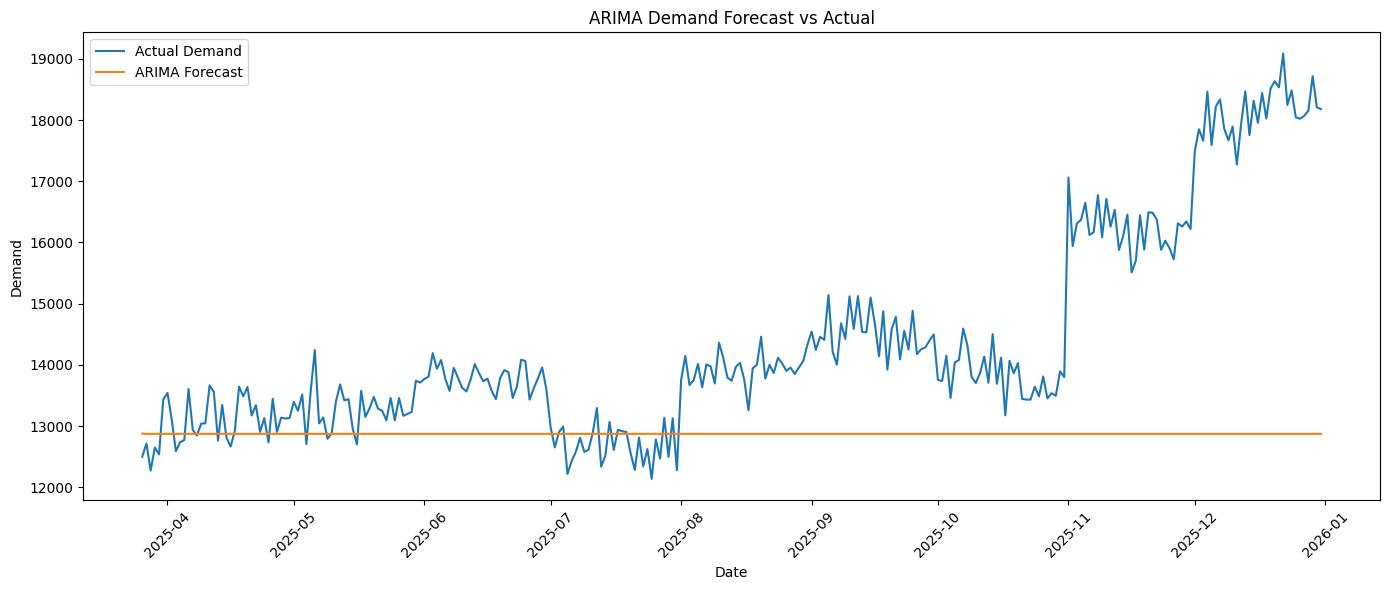

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test['date'],
    test['demand'],
    label='Actual Demand'
)

plt.plot(
    test['date'],
    arima_forecast.values,
    label='ARIMA Forecast'
)

plt.title('ARIMA Demand Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [32]:
# ============================================================
# SARIMA MODEL
# ============================================================

sarima_model = SARIMAX(
    train['demand'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            demand   No. Observations:                 1122
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -8427.228
Date:                           Mon, 24 Aug 2026   AIC                          16864.456
Time:                                   19:24:32   BIC                          16889.494
Sample:                                        0   HQIC                         16873.926
                                          - 1122                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1414      0.128     -1.103      0.270      -0.393       0.110
ma.L1         -0.1244      0.129     -0.966

In [33]:
# Generate forecast for the test period

sarima_forecast = sarima_fit.forecast(
    steps=len(test)
)

print("SARIMA Forecast:")
print(sarima_forecast.head())

SARIMA Forecast:
1122    12773.784141
1123    12759.868085
1124    12826.911045
1125    12793.616928
1126    12850.505180
Name: predicted_mean, dtype: float64


In [34]:
# ============================================================
# SARIMA EVALUATION
# ============================================================

sarima_mae = mean_absolute_error(
    test['demand'],
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test['demand'],
        sarima_forecast
    )
)

sarima_mape = np.mean(
    np.abs(
        (test['demand'].values - sarima_forecast.values)
        / test['demand'].values
    )
) * 100

print("\nSARIMA Results")
print("-" * 30)
print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")


SARIMA Results
------------------------------
MAE  : 1644.34
RMSE : 2325.24
MAPE : 10.42%


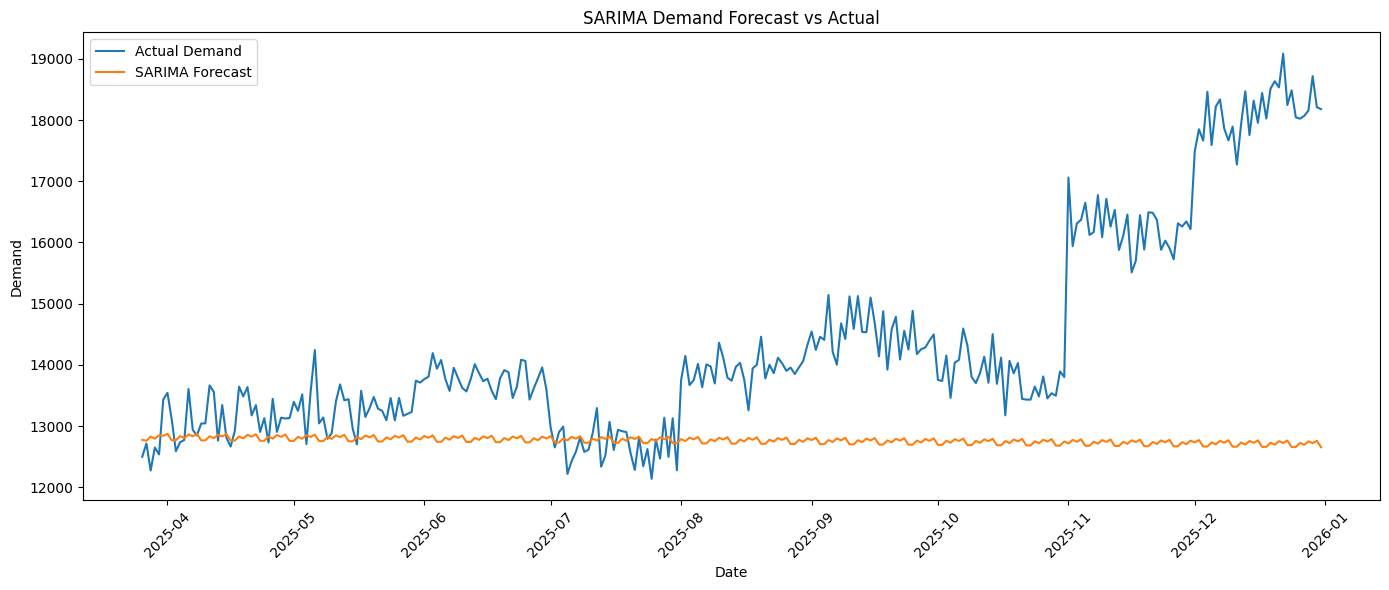

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test['date'],
    test['demand'],
    label='Actual Demand'
)

plt.plot(
    test['date'],
    sarima_forecast.values,
    label='SARIMA Forecast'
)

plt.title('SARIMA Demand Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
features = [
    'year',
    'month',
    'quarter',
    'day_of_week',
    'day',
    'week_of_year',
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'lag_30',
    'rolling_7',
    'rolling_14',
    'rolling_28',
    'rolling_30',
    'rolling_std_7'
]

X_train = train[features]
y_train = train['demand']

X_test = test[features]
y_test = test['demand']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1122, 17)
y_train: (1122,)
X_test: (281, 17)
y_test: (281,)


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model_improved = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model_improved.fit(X_train, y_train)

rf_improved_pred = rf_model_improved.predict(X_test)

print("Improved Random Forest trained successfully.")

Improved Random Forest trained successfully.


In [38]:
rf_improved_mae = mean_absolute_error(y_test, rf_improved_pred)
rf_improved_rmse = np.sqrt(mean_squared_error(y_test, rf_improved_pred))
rf_improved_mape = np.mean(
    np.abs((y_test - rf_improved_pred) / y_test)
) * 100

print("Improved Random Forest Results")
print("--------------------------------")
print("MAE :", rf_improved_mae)
print("RMSE:", rf_improved_rmse)
print("MAPE:", rf_improved_mape, "%")

Improved Random Forest Results
--------------------------------
MAE : 429.4495729537366
RMSE: 540.884422050336
MAPE: 2.9503544506419663 %


In [39]:
seasonal_naive_pred = test['lag_7']

seasonal_naive_mae = mean_absolute_error(y_test, seasonal_naive_pred)
seasonal_naive_rmse = np.sqrt(
    mean_squared_error(y_test, seasonal_naive_pred)
)
seasonal_naive_mape = np.mean(
    np.abs((y_test - seasonal_naive_pred) / y_test)
) * 100

print("Seasonal Naive (7-day) Results")
print("--------------------------------")
print("MAE :", seasonal_naive_mae)
print("RMSE:", seasonal_naive_rmse)
print("MAPE:", seasonal_naive_mape, "%")

Seasonal Naive (7-day) Results
--------------------------------
MAE : 488.0498220640569
RMSE: 733.7615901465389
MAPE: 3.3375807051384787 %


In [40]:
model_comparison = pd.DataFrame({
    'Model': [
        'Naive Baseline',
        'Random Forest',
        'XGBoost',
        'Improved Random Forest',
        'Seasonal Naive (7-day)'
    ],
    'MAE': [
        baseline_mae,
        mae,
        xgb_mae,
        rf_improved_mae,
        seasonal_naive_mae
    ],
    'RMSE': [
        baseline_rmse,
        rmse,
        xgb_rmse,
        rf_improved_rmse,
        seasonal_naive_rmse
    ],
    'MAPE (%)': [
        baseline_mape,
        mape,
        xgb_mape,
        rf_improved_mape,
        seasonal_naive_mape
    ]
})

model_comparison.sort_values('MAPE (%)')

,Model,MAE,RMSE,MAPE (%)
0,Naive Baseline,366.526132,486.847725,2.557459
1,Random Forest,414.749512,524.615518,2.857986
2,XGBoost,417.448853,521.340070,2.874982
3,Improved Random Forest,429.449573,540.884422,2.950354
4,Seasonal Naive (7-day),488.049822,733.761590,3.337581


In [41]:
baseline_pred_current = test['lag_1']

In [42]:
print("test:", len(test))
print("y_test:", len(y_test))
print("baseline_pred:", len(baseline_pred))
print("current lag_1:", len(test['lag_1']))

test: 281
y_test: 281
baseline_pred: 287
current lag_1: 281


In [43]:
baseline_pred_current = test['lag_1'].copy()

print("Prediction length:", len(baseline_pred_current))

Prediction length: 281


In [44]:
forecast_results = pd.DataFrame({
    'date': test['date'].values,
    'actual_demand': y_test.values,
    'predicted_demand': baseline_pred_current.values
})

print("Forecast results shape:", forecast_results.shape)
forecast_results.head()

Forecast results shape: (281, 3)


,date,actual_demand,predicted_demand
0,2025-03-26,12497,12837.0
1,2025-03-27,12714,12497.0
2,2025-03-28,12272,12714.0
3,2025-03-29,12648,12272.0
4,2025-03-30,12536,12648.0


In [45]:
forecast_results['error'] = (
    forecast_results['actual_demand']
    - forecast_results['predicted_demand']
)

forecast_results['absolute_error'] = (
    forecast_results['error'].abs()
)

forecast_results.head()

,date,actual_demand,predicted_demand,error,absolute_error
0,2025-03-26,12497,12837.0,-340.0,340.0
1,2025-03-27,12714,12497.0,217.0,217.0
2,2025-03-28,12272,12714.0,-442.0,442.0
3,2025-03-29,12648,12272.0,376.0,376.0
4,2025-03-30,12536,12648.0,-112.0,112.0


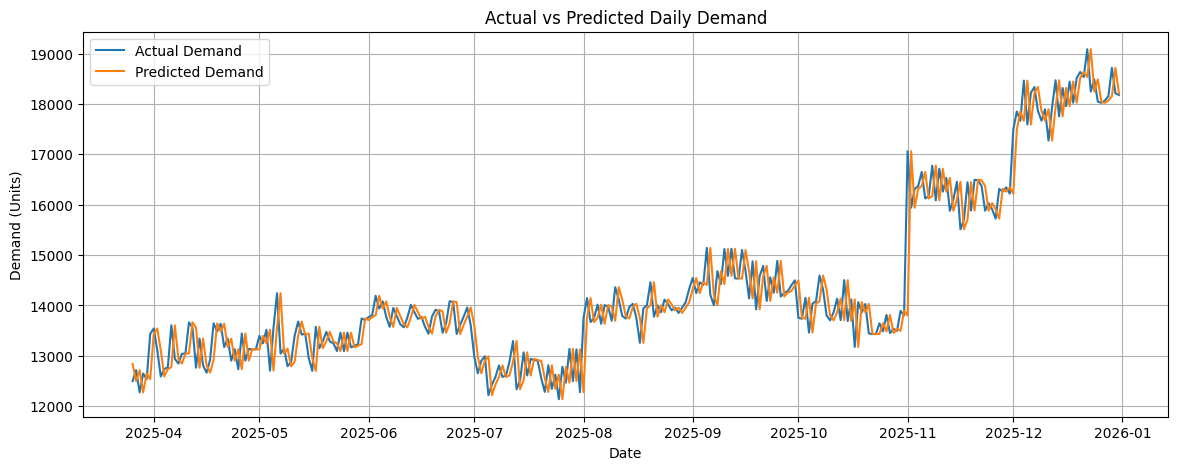

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    forecast_results['date'],
    forecast_results['actual_demand'],
    label='Actual Demand'
)

plt.plot(
    forecast_results['date'],
    forecast_results['predicted_demand'],
    label='Predicted Demand'
)

plt.title('Actual vs Predicted Daily Demand')
plt.xlabel('Date')
plt.ylabel('Demand (Units)')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
forecast_output_path = os.path.join(
    processed_path,
    "demand_forecast_results.csv"
)

forecast_results.to_csv(
    forecast_output_path,
    index=False
)

print("Forecast results saved successfully.")
print("Rows:", len(forecast_results))

Forecast results saved successfully.
Rows: 281
